# ERA5 multi-winter blocking benchmark

This notebook is the next step after the two-window TM1990 demonstration. It
uses the same detector over five complete December–February winters:
2020–21 through 2024–25. The purpose is **not** to claim a final blocking
climatology. The purpose is to test whether the diagnostic produces a
stable, interpretable longitude pattern before we use it to evaluate EERIE.

The notebook answers four practical questions:

1. Did we download complete, regular 6-hourly 500 hPa fields?
2. How often does the raw gradient rule identify a candidate?
3. How much does the 20° sector filter reduce those candidates?
4. Does the pooled longitude pattern look physically interpretable, or does
   the implementation need correction before we continue?

Only Z500 is downloaded for this benchmark. Wind and surface pressure are not
needed for TM1990, so the Z500-only cache avoids repeating the much larger
wind download. The results are still a pilot benchmark: five winters are
useful for validation, but not enough for a publication-quality climatology.


In [1]:
# Set up the five-winter benchmark and load the Z500-only ERA5 loader.
# ruff: noqa: E402
import sys
from datetime import datetime
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import xarray as xr
import yaml
from IPython.display import display

from eurogrid.data.era5 import load_era5_z500
from eurogrid.diagnostics.blocking import detect_tm1990, persistence_summary

with open(ROOT / "config/settings.yaml") as handle:
    cfg = yaml.safe_load(handle)

blocking_cfg = cfg["blocking"]
benchmark_windows = blocking_cfg["benchmark_windows"]

In [2]:
# Load or create the five local Z500 caches and verify their dimensions.
z500_by_winter = {}
inventory_rows = []
for window in benchmark_windows:
    z500 = load_era5_z500(
        datetime.fromisoformat(window["start"]),
        datetime.fromisoformat(window["end"]),
        **blocking_cfg["domain"],
        cache_dir=ROOT / cfg["era5"]["cache_dir"],
        z500_stride_hours=cfg["era5"]["z500_stride_hours"],
    )
    z500_by_winter[window["label"]] = z500
    inventory_rows.append(
        {
            "winter": window["label"],
            "timesteps": z500.sizes["time_z500"],
            "latitudes": z500.sizes["lat"],
            "longitudes": z500.sizes["lon"],
            "lat_range": f"{float(z500.lat.max()):g} to {float(z500.lat.min()):g}°N",
            "lon_range": f"{float(z500.lon.min()):g} to {float(z500.lon.max()):g}°E",
            "first_utc": str(z500.time_z500.values[0])[:16],
            "last_utc": str(z500.time_z500.values[-1])[:16],
        }
    )
inventory = pl.DataFrame(inventory_rows)
display(inventory)

winter,timesteps,latitudes,longitudes,lat_range,lon_range,first_utc,last_utc
str,i64,i64,i64,str,str,str,str
"""2020-21""",360,221,321,"""85 to 30°N""","""-40 to 40°E""","""2020-12-01T00:00""","""2021-02-28T18:00"""
"""2021-22""",360,221,321,"""85 to 30°N""","""-40 to 40°E""","""2021-12-01T00:00""","""2022-02-28T18:00"""
"""2022-23""",360,221,321,"""85 to 30°N""","""-40 to 40°E""","""2022-12-01T00:00""","""2023-02-28T18:00"""
"""2023-24""",364,221,321,"""85 to 30°N""","""-40 to 40°E""","""2023-12-01T00:00""","""2024-02-29T18:00"""
"""2024-25""",360,221,321,"""85 to 30°N""","""-40 to 40°E""","""2024-12-01T00:00""","""2025-02-28T18:00"""


**Table — benchmark data inventory.** Every row should contain a complete
December–February window, 6-hourly timestamps, the expanded 30–85°N domain,
and the same longitude grid. This is a data-completeness check before any
frequency is interpreted. The cache contains only `z500`, because TM1990
uses geopotential height rather than wind or generation.


In [3]:
# Apply TM1990 to each winter and turn detector output into understandable metrics.
results = {}
persistence = {}
summary_rows = []
for label, z500 in z500_by_winter.items():
    result = detect_tm1990(
        z500,
        phi0_deg=blocking_cfg["phi0_deg"],
        arm_deg=blocking_cfg["arm_deg"],
        scan_offsets_deg=tuple(blocking_cfg["scan_offsets_deg"]),
        ghgn_threshold_m_per_deg=blocking_cfg["ghgn_threshold_m_per_deg"],
        min_sector_width_deg=blocking_cfg["min_sector_width_deg"],
    )
    summary_result = persistence_summary(
        result.blocking,
        timestep_hours=cfg["era5"]["z500_stride_hours"],
        min_persistence_days=blocking_cfg["min_persistence_days"],
    )
    results[label] = result
    persistence[label] = summary_result
    longitude_step = float(z500.lon.diff("lon").median())
    summary_rows.append(
        {
            "winter": label,
            "candidate_percent": 100 * float(result.candidate.mean()),
            "sector_percent": 100 * float(result.blocking.mean()),
            "persistent_percent": 100 * float(summary_result.persistent_blocking.mean()),
            "typical_blocked_span_deg": longitude_step
            * float(summary_result.blocking_longitude_count.mean()),
            "widest_blocked_span_deg": longitude_step * float(summary_result.blocking_longitude_count.max()),
        }
    )
summary_numeric = pl.DataFrame(summary_rows)
summary = summary_numeric.with_columns(
    pl.col("candidate_percent")
    .map_elements(lambda value: f"{value:.1f}%", return_dtype=pl.String)
    .alias("raw_gradient_candidates"),
    pl.col("sector_percent")
    .map_elements(lambda value: f"{value:.1f}%", return_dtype=pl.String)
    .alias("20_degree_sector"),
    pl.col("persistent_percent")
    .map_elements(lambda value: f"{value:.1f}%", return_dtype=pl.String)
    .alias("five_day_persistent"),
    pl.col("typical_blocked_span_deg")
    .map_elements(lambda value: f"{value:.1f}°", return_dtype=pl.String)
    .alias("typical_span"),
    pl.col("widest_blocked_span_deg")
    .map_elements(lambda value: f"{value:.1f}°", return_dtype=pl.String)
    .alias("widest_span"),
)
summary = summary.select(
    [
        "winter",
        "raw_gradient_candidates",
        "20_degree_sector",
        "five_day_persistent",
        "typical_span",
        "widest_span",
    ]
)
display(summary)

winter,raw_gradient_candidates,20_degree_sector,five_day_persistent,typical_span,widest_span
str,str,str,str,str,str
"""2020-21""","""9.5%""","""5.1%""","""0.0%""","""4.1°""","""68.8°"""
"""2021-22""","""11.8%""","""8.6%""","""0.0%""","""6.9°""","""69.2°"""
"""2022-23""","""16.9%""","""14.1%""","""21.4%""","""11.3°""","""61.0°"""
"""2023-24""","""7.3%""","""4.9%""","""8.0%""","""3.9°""","""68.8°"""
"""2024-25""","""15.7%""","""10.9%""","""13.9%""","""8.7°""","""64.8°"""


**Table — what happened in each winter.** Each percentage answers a different question. *Raw gradient candidates* is the share of all 6-hourly longitude checks where the local 40°N–60°N–80°N height shape passed. *20° sector* is the share that remained after requiring neighboring longitudes to form a physically extended sector. *Five-day persistent* is the share of times belonging to a blocking episode lasting at least five days. The last two columns express the detected longitude width in degrees; they are easier to interpret than the computer count of 0.25° grid cells.

The word `f64` only described the computer storage type: a 64-bit decimal number. It is not a climate quantity, uncertainty, or quality flag, so it has been removed from the displayed table. For example, 0.094592 becomes 9.5%: about 9 or 10 out of every 100 time–longitude checks.


### How to read one row

Take winter 2022–23 as an example. The raw gradient test passed at roughly 16.9% of the time–longitude checks. After asking for a connected sector at least 20° wide, about 14.1% remained. The five-day filter then identifies about 21.4% of timestamps as part of long-lived blocking periods. These are successive filters, not three independent estimates of the same thing. The typical detected span was about 11.3° (45 grid cells × 0.25°), while the widest instantaneous span reached about 61°. A wide maximum is a quality-control value: it says that at least one timestep had a broad detected sector, not that the whole winter was blocked.


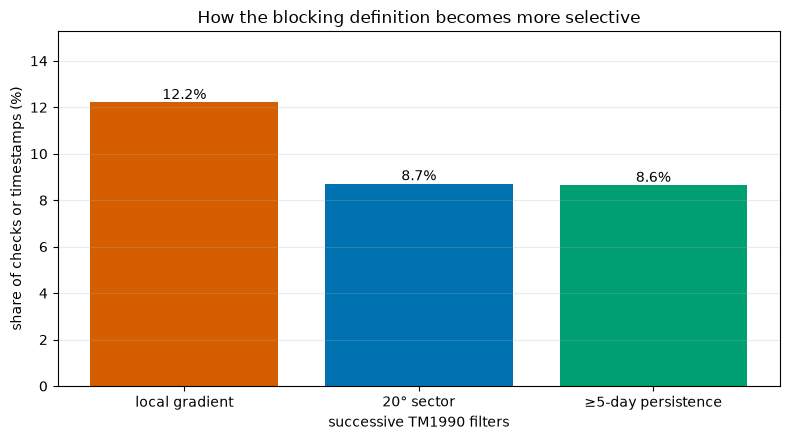

In [4]:
# Show the detector as a simple funnel from local shape to persistent event.
funnel = summary_numeric.select(["candidate_percent", "sector_percent", "persistent_percent"]).mean()
funnel_labels = ["local gradient", "20° sector", "≥5-day persistence"]
funnel_values = [
    float(funnel[column][0]) for column in ["candidate_percent", "sector_percent", "persistent_percent"]
]
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(funnel_labels, funnel_values, color=["#D55E00", "#0072B2", "#009E73"])
ax.set(
    xlabel="successive TM1990 filters",
    ylabel="share of checks or timestamps (%)",
    title="How the blocking definition becomes more selective",
)
ax.bar_label(bars, fmt="%.1f%%")
ax.set_ylim(0, max(funnel_values) * 1.25)
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()

*Figure — detector funnel. The first bar counts local height-gradient candidates, the second keeps only candidates connected into a 20° longitude sector, and the third keeps timestamps that belong to episodes lasting at least five days. The first two bars are time–longitude checks; the last bar is a time fraction after persistence is evaluated. Because the denominators differ slightly, this is an explanatory quality-control figure rather than a probability model. Source: ERA5/ARCO Z500-only local caches; analysis: TM1990 detector.*


/home/ubuntu/repos/EuroGrid-Climate-Dynamics/.venv/lib/python3.11/site-packages/xarray/core/dataarray.py:6446: FutureWarning: Behaviour of argmin/argmax with neither dim nor axis argument will change to return a dict of indices of each dimension. To get a single, flat index, please use np.argmin(da.data) or np.argmax(da.data) instead of da.argmin() or da.argmax().
  result = self.variable.argmax(dim, axis, keep_attrs, skipna)


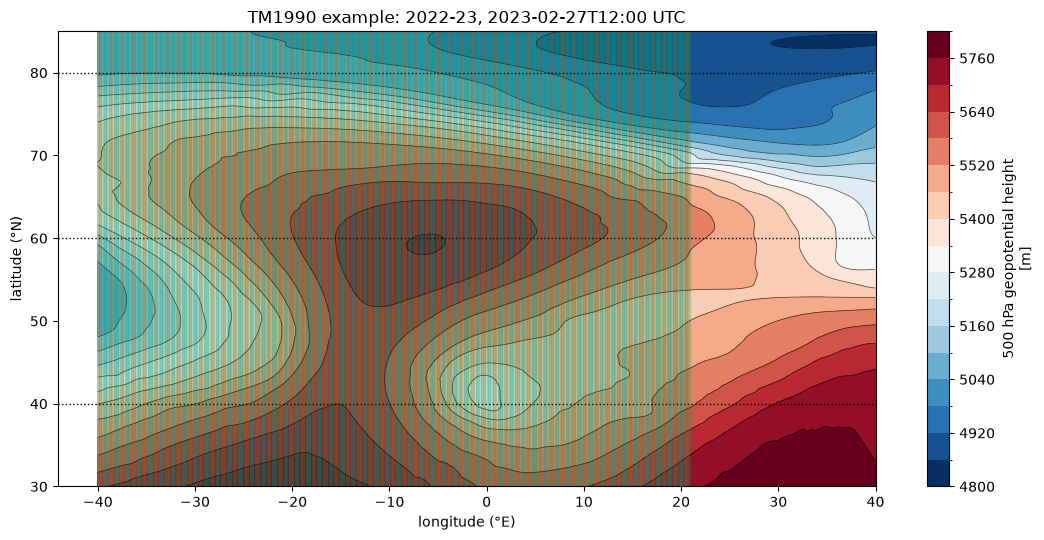

In [5]:
# Map one selected Z500 field and overlay the longitude masks used by TM1990.
selected_label = "2022-23"
selected_result = results[selected_label]
selected_persistence = persistence[selected_label]
selected_index = int(selected_result.blocking.sum("lon").argmax())
selected_z500 = z500_by_winter[selected_label].isel(time_z500=selected_index)
selected_candidate = selected_result.candidate.isel(time_z500=selected_index)
selected_blocking = selected_result.blocking.isel(time_z500=selected_index)
selected_lons = selected_z500.lon.values
candidate_lons = selected_lons[selected_candidate.values]
blocking_lons = selected_lons[selected_blocking.values]
fig, ax = plt.subplots(figsize=(11, 5.5))
levels = np.arange(
    float(selected_z500.min()) // 60 * 60,
    float(selected_z500.max()) // 60 * 60 + 120,
    60,
)
selected_z500.plot.contourf(ax=ax, levels=levels, cmap="RdBu_r", add_colorbar=True)
selected_z500.plot.contour(ax=ax, levels=levels, colors="black", linewidths=0.55, alpha=0.65)
for latitude in [40, 60, 80]:
    ax.axhline(latitude, color="black", linestyle=":", linewidth=1)
for longitude in blocking_lons:
    ax.axvspan(longitude - 0.125, longitude + 0.125, color="#009E73", alpha=0.22)
for longitude in candidate_lons:
    ax.axvline(longitude, color="#D55E00", linewidth=0.45, alpha=0.35)
ax.set(
    xlabel="longitude (°E)",
    ylabel="latitude (°N)",
    title=f"TM1990 example: {selected_label}, {str(selected_z500.time_z500.values)[:16]} UTC",
)
fig.tight_layout()
plt.show()

*Figure — one physical example behind the masks. The colored contours show the actual ERA5 500 hPa geopotential-height field used by TM1990. The dotted lines mark the three latitude bands used by the calculation: 40°N, 60°N, and 80°N. Thin orange lines mark longitudes that pass the local gradient test; green shading marks the subset that also belongs to a connected 20° sector. This is why the final blocking result is a longitude mask: the detector samples the height field along those three latitude bands and then asks where the pattern is spatially continuous in longitude. Source: ERA5/ARCO Z500 local cache; one 6-hourly timestep from 2022–23.*


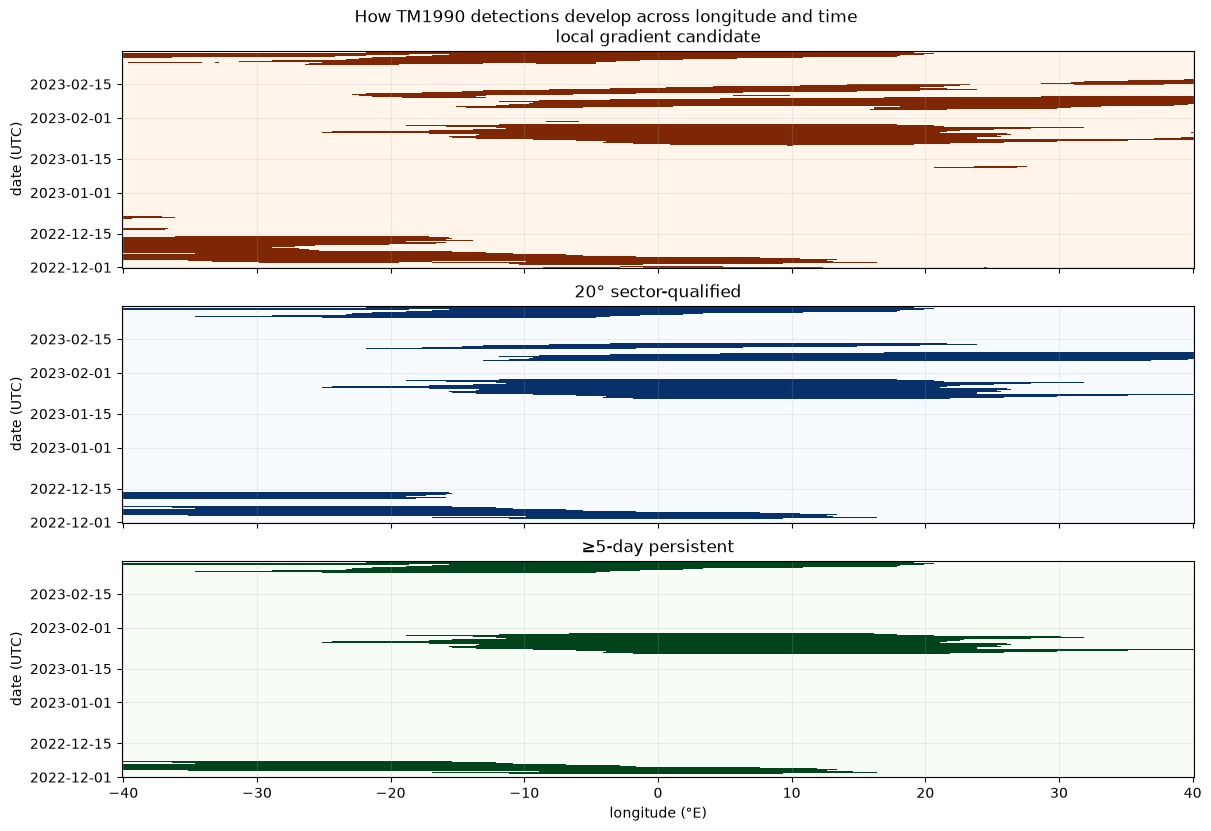

In [6]:
# Show how candidate, sector, and persistent masks evolve through one winter.
persistent_mask = selected_result.blocking & selected_persistence.persistent_blocking
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True, constrained_layout=True)
mask_specs = [
    (selected_result.candidate, "local gradient candidate", "Oranges"),
    (selected_result.blocking, "20° sector-qualified", "Blues"),
    (persistent_mask, "≥5-day persistent", "Greens"),
]
for ax, (mask, label, cmap) in zip(axes, mask_specs, strict=True):
    values = mask.astype(int)
    ax.pcolormesh(
        values.lon,
        values.time_z500,
        values,
        shading="auto",
        cmap=cmap,
        vmin=0,
        vmax=1,
    )
    ax.set_ylabel("date (UTC)")
    ax.set_title(label)
    ax.grid(alpha=0.2)
axes[-1].set_xlabel("longitude (°E)")
fig.suptitle("How TM1990 detections develop across longitude and time", y=1.02)
plt.show()

*Figure — longitude–time view of the same winter. Each colored pixel is one longitude at one 6-hourly time. The top panel shows where the local height-gradient shape passes, the middle panel shows where those pixels connect into a 20° sector, and the bottom panel shows only times belonging to an episode lasting at least five days. Read downward as successive scientific filters and read left-to-right as longitude. This view is often easier than a single summary percentage because it shows whether detections are isolated speckles, connected patches, or long-lived blocks. Source: ERA5/ARCO; analysis: TM1990 masks.*


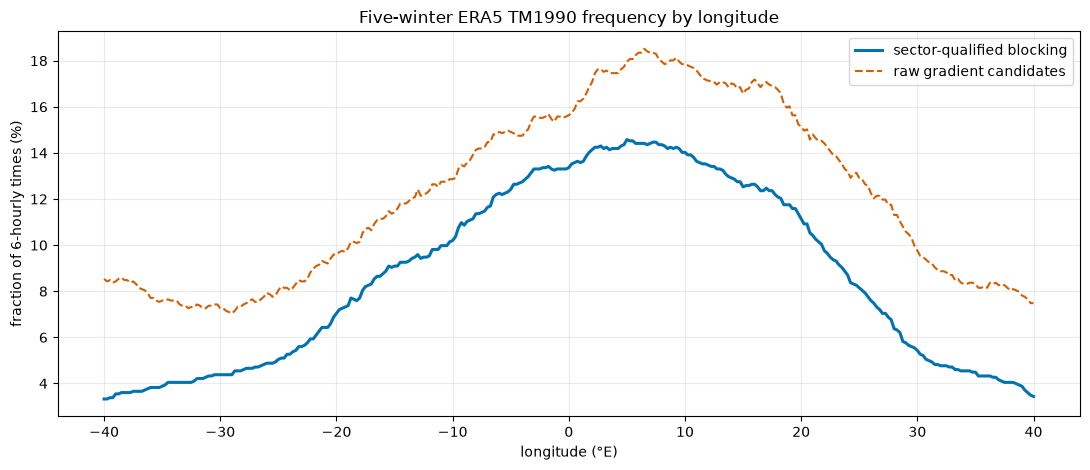

In [7]:
# Combine the five winters into a longitude-frequency benchmark.
blocking_frequency = xr.concat(
    [results[label].blocking for label in results],
    dim="time_z500",
).mean("time_z500")
candidate_frequency = xr.concat(
    [results[label].candidate for label in results],
    dim="time_z500",
).mean("time_z500")
fig, ax = plt.subplots(figsize=(11, 4.8))
ax.plot(
    blocking_frequency.lon,
    100 * blocking_frequency,
    label="sector-qualified blocking",
    color="#0072B2",
    linewidth=2.2,
)
ax.plot(
    candidate_frequency.lon,
    100 * candidate_frequency,
    label="raw gradient candidates",
    color="#D55E00",
    linestyle="--",
)
ax.set(
    xlabel="longitude (°E)",
    ylabel="fraction of 6-hourly times (%)",
    title="Five-winter ERA5 TM1990 frequency by longitude",
)
ax.grid(alpha=0.25)
ax.legend()
fig.tight_layout()
plt.show()

*Figure — pooled longitude frequency. For each longitude, we first ask: “At what percentage of 6-hourly times did the local 40°N–60°N–80°N height shape pass?” That is the dashed orange curve. We then ask the stricter question: “At what percentage of times did that longitude belong to a connected sector at least 20° wide?” That is the solid blue curve. A higher point means that blocking-like conditions were detected more often at that longitude in this five-winter sample; it does **not** mean stronger blocking or a causal effect. The two curves differ because the sector rule removes isolated single-longitude detections. Source: ERA5/ARCO Z500-only local caches; analysis: the same TM1990 detector used in the teaching notebook. This is a pilot benchmark, not a final climatological frequency.*


winter,candidate_percent,sector_percent
str,f64,f64
"""2020-21""",9.459155,5.126341
"""2021-22""",11.768778,8.599862
"""2022-23""",16.884735,14.095708
"""2023-24""",7.283215,4.882578
"""2024-25""",15.681031,10.876601


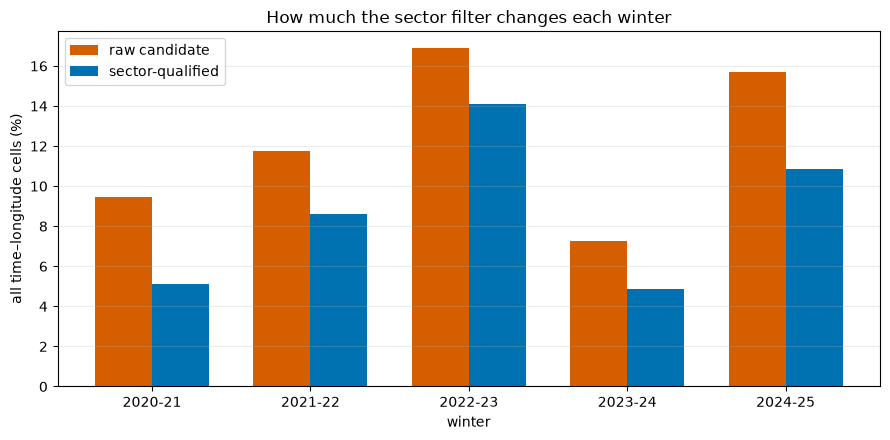

In [8]:
# Compare the candidate and sector-qualified frequencies by winter.
frequency_rows = []
for label, result in results.items():
    frequency_rows.append(
        {
            "winter": label,
            "candidate_percent": 100 * float(result.candidate.mean()),
            "sector_percent": 100 * float(result.blocking.mean()),
        }
    )
frequency_by_winter = pl.DataFrame(frequency_rows)
display(frequency_by_winter)
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(frequency_by_winter))
width = 0.36
ax.bar(
    x - width / 2,
    frequency_by_winter["candidate_percent"],
    width,
    label="raw candidate",
    color="#D55E00",
)
ax.bar(
    x + width / 2,
    frequency_by_winter["sector_percent"],
    width,
    label="sector-qualified",
    color="#0072B2",
)
ax.set(
    xticks=x,
    xticklabels=frequency_by_winter["winter"],
    xlabel="winter",
    ylabel="all time–longitude cells (%)",
    title="How much the sector filter changes each winter",
)
ax.legend()
ax.grid(axis="y", alpha=0.25)
fig.tight_layout()
plt.show()

*Figure — winter-to-winter stability check. The orange bars show how often the local height-gradient shape appears anywhere in the domain. The blue bars show how often it also forms a connected 20° sector. A lower blue bar is expected because it is a stricter definition. Differences between winters are not automatically trends: five winters are too few, and natural variability can be large. Source: ERA5/ARCO; analysis: TM1990.*


In [9]:
# Report the benchmark's most frequent longitudes and the correct interpretation.
top_indices = np.argsort(blocking_frequency.values)[-5:][::-1]
top_longitudes = [
    {
        "longitude_deg_e": float(blocking_frequency.lon.values[index]),
        "frequency_percent": 100 * float(blocking_frequency.values[index]),
    }
    for index in top_indices
]
display(pl.DataFrame(top_longitudes))

longitude_deg_e,frequency_percent
f64,f64
5.0,14.578714
5.25,14.523282
5.5,14.523282
7.25,14.467849
7.5,14.467849


## What this benchmark can tell us

The inventory confirms that all five winters use the same 6-hourly ERA5 Z500 grid and the same 30–85°N, −40–40°E domain. The detector funnel shows how each scientific definition narrows the result: a local height pattern is not yet a sector, and a sector is not yet a persistent episode. The longitude plot then asks whether the surviving detections are spread across a coherent region or appear as isolated grid-point noise.

In this pilot, the winters differ noticeably. That is useful information: blocking is variable, and a five-winter average should not be mistaken for a stable climatology. Before model evaluation, we should compare this longitude structure with an independent published blocking climatology and, if needed, investigate detector sensitivity to sector width and thresholds.

## What it cannot tell us yet

Five winters cannot establish a robust climatology or trend. This diagnostic alone cannot prove that blocking causes wind droughts, generation stress, or any effect of ocean coupling. It is a historical benchmark and quality-control step.

## Recommended next step

After you are comfortable with this benchmark, the next historical analysis is a Dunkelflaute threshold sweep using ERA5 wind/solar proxies and SMARD generation. That step will show how different drought definitions change the number, duration, and overlap of low-renewable events. EERIE should follow only after these historical diagnostics are understandable and stable.
